#Import Required Libraries

In [ ]:
# Basic setup
from google.colab import files
import io
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# NLP & modeling
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Download needed NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

#Uplaod and Combine Multiple CSVs

In [ ]:
print("📦 Please upload your ZIP file containing CSVs (e.g., tweets.zip):")
uploaded = files.upload()

📦 Please upload your ZIP file containing CSVs (e.g., tweets.zip):


Saving archive.zip to archive.zip


In [ ]:
dfs = {}
for zipname in uploaded:
    with zipfile.ZipFile(io.BytesIO(uploaded[zipname])) as zf:
        for filename in zf.namelist():
            if filename.endswith('.csv'):
                try:
                    with zf.open(filename) as f:
                        df = pd.read_csv(f, low_memory=False)
                        dfs[filename] = df
                        print(f"✅ Loaded {filename} → shape {df.shape}")
                except Exception as e:
                    print(f"⚠️ Failed to read {filename} as CSV: {e}")

# Summary
if len(dfs) == 1:
    df = next(iter(dfs.values()))
    print(f"\n✅ Loaded single DataFrame with shape {df.shape}")
else:
    print("\n📊 You have multiple DataFrames in `dfs` dict:")
    for fn, frame in dfs.items():
        print(f" • {fn} → shape {frame.shape}")

✅ Loaded tweets/data_analysis.csv → shape (39116, 36)
✅ Loaded tweets/data_science.csv → shape (241386, 36)
✅ Loaded tweets/data_visualization.csv → shape (33590, 36)

📊 You have multiple DataFrames in `dfs` dict:
 • tweets/data_analysis.csv → shape (39116, 36)
 • tweets/data_science.csv → shape (241386, 36)
 • tweets/data_visualization.csv → shape (33590, 36)


#Inspect Sample Columns of Each Dataframe

In [ ]:
for fn in dfs.keys():
    print(f"{fn} columns (first 10):", dfs[fn].columns[:10].tolist())

tweets/data_analysis.csv columns (first 10): ['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone', 'user_id', 'username', 'name', 'place']
tweets/data_science.csv columns (first 10): ['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone', 'user_id', 'username', 'name', 'place']
tweets/data_visualization.csv columns (first 10): ['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone', 'user_id', 'username', 'name', 'place']


#Tag by Source & Combine into df_all

In [ ]:
# Add a column 'source_file' to each, then concat
for fn, df_part in dfs.items():
    df_part['source_file'] = fn

df_all = pd.concat(dfs.values(), ignore_index=True)
print(f"\nCombined DataFrame shape: {df_all.shape}")
print("Combined columns:", df_all.columns.tolist())



Combined DataFrame shape: (314092, 37)
Combined columns: ['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone', 'user_id', 'username', 'name', 'place', 'tweet', 'language', 'mentions', 'urls', 'photos', 'replies_count', 'retweets_count', 'likes_count', 'hashtags', 'cashtags', 'link', 'retweet', 'quote_url', 'video', 'thumbnail', 'near', 'geo', 'source', 'user_rt_id', 'user_rt', 'retweet_id', 'reply_to', 'retweet_date', 'translate', 'trans_src', 'trans_dest', 'source_file']


#Compute Sentiment and Labels

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize analyzer
sia = SentimentIntensityAnalyzer()

# Function to map compound score → label
def get_sentiment_label(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply to create `label` column
df_all['label'] = df_all['tweet'].apply(get_sentiment_label)
print("Label value counts:\n", df_all['label'].value_counts())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Label value counts:
 label
positive    152876
neutral     130049
negative     31167
Name: count, dtype: int64


#Drop any rows missing `tweet` (labels now auto‑computed)


In [ ]:
df_all = df_all.dropna(subset=['tweet'])
print("After dropping missing tweets:", df_all.shape)

# Show label distribution by source
print(df_all.groupby(['source_file','label']).size().unstack(fill_value=0))

After dropping missing tweets: (314092, 38)
label                          negative  neutral  positive
source_file                                               
tweets/data_analysis.csv           5537    13846     19733
tweets/data_science.csv           23117   102570    115699
tweets/data_visualization.csv      2513    13633     17444


#Quick EDA


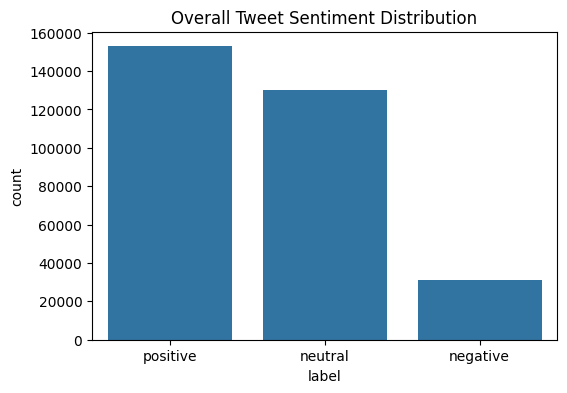

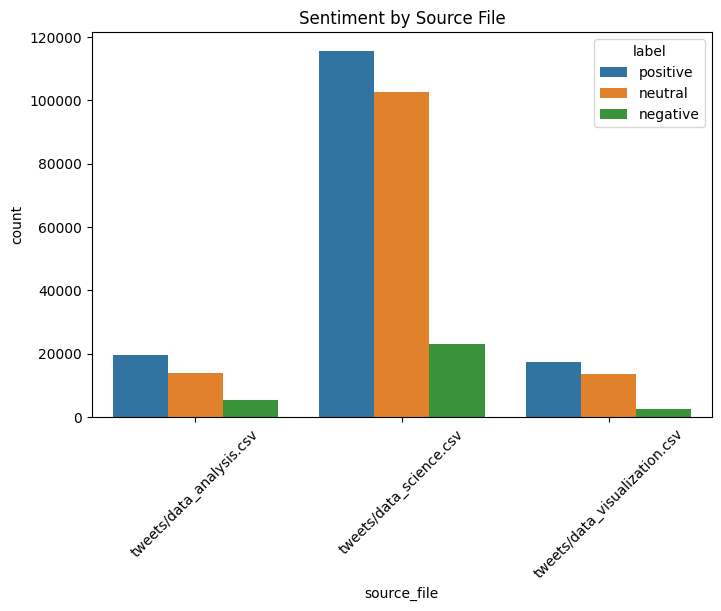

In [ ]:
# Overall sentiment distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_all)
plt.title('Overall Tweet Sentiment Distribution')
plt.show()

# Sentiment distribution per source file
plt.figure(figsize=(8,5))
sns.countplot(x='source_file', hue='label', data=df_all)
plt.title('Sentiment by Source File')
plt.xticks(rotation=45)
plt.show()

##Separate graphs per sentiment

<ipython-input-16-bcba8c8b0803>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='source_file', data=subset, palette='Set2')
<ipython-input-16-bcba8c8b0803>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='source_file', data=subset, palette='Set2')
<ipython-input-16-bcba8c8b0803>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='source_file', data=subset, palette='Set2')
<ipython-input-16-bcba8c8b0803>:17: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.1

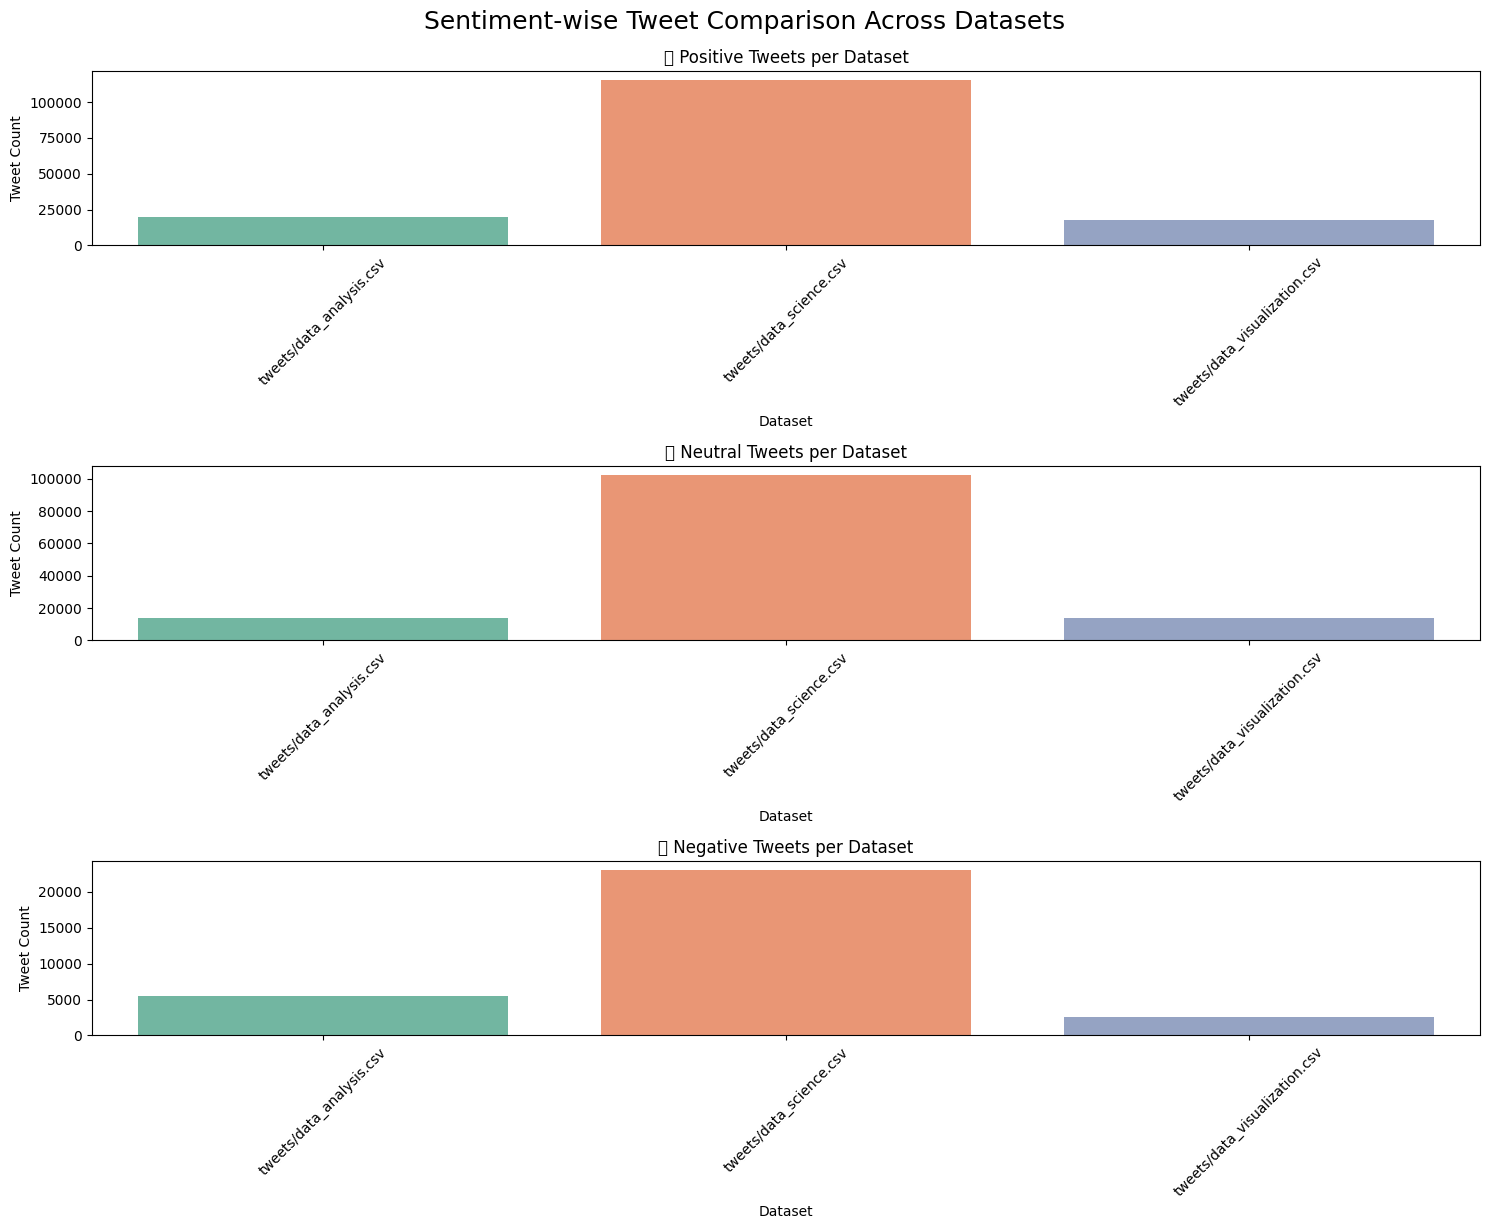

In [ ]:
if 'label' not in df_all.columns or 'source_file' not in df_all.columns:
    raise ValueError("❌ 'df_all' must have 'label' and 'source_file' columns.")

sentiments = ['positive', 'neutral', 'negative']

plt.figure(figsize=(15, 12))

for i, sentiment in enumerate(sentiments, start=1):
    plt.subplot(3, 1, i)
    subset = df_all[df_all['label'] == sentiment]
    sns.countplot(x='source_file', data=subset, palette='Set2')
    plt.title(f"📊 {sentiment.capitalize()} Tweets per Dataset")
    plt.xlabel('Dataset')
    plt.ylabel('Tweet Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle("Sentiment-wise Tweet Comparison Across Datasets", fontsize=18, y=1.02)
plt.show()


##Tweet Length Distribution

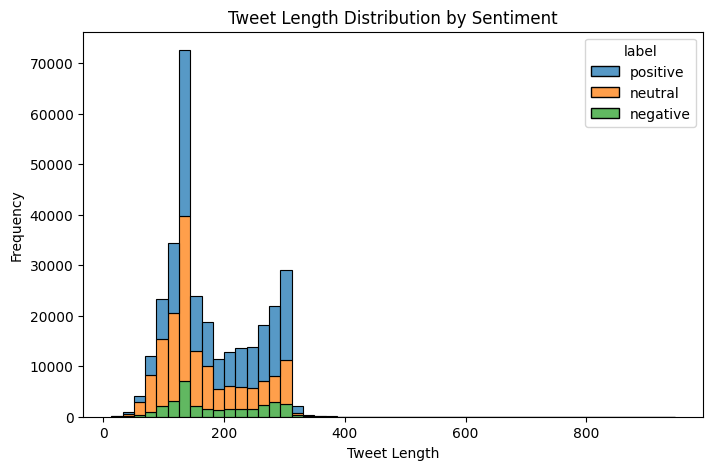

In [ ]:
df_all['tweet_length'] = df_all['tweet'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df_all, x='tweet_length', bins=50, hue='label', multiple='stack')
plt.title('Tweet Length Distribution by Sentiment')
plt.xlabel('Tweet Length')
plt.ylabel('Frequency')
plt.show()

##Tweets over Time

<ipython-input-18-171fef1ce7b0>:1: FutureWarning: Parsed string "2021-06-20 05:15:24 IST" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df_all['created_at'] = pd.to_datetime(df_all['created_at'], errors='coerce')
<ipython-input-18-171fef1ce7b0>:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


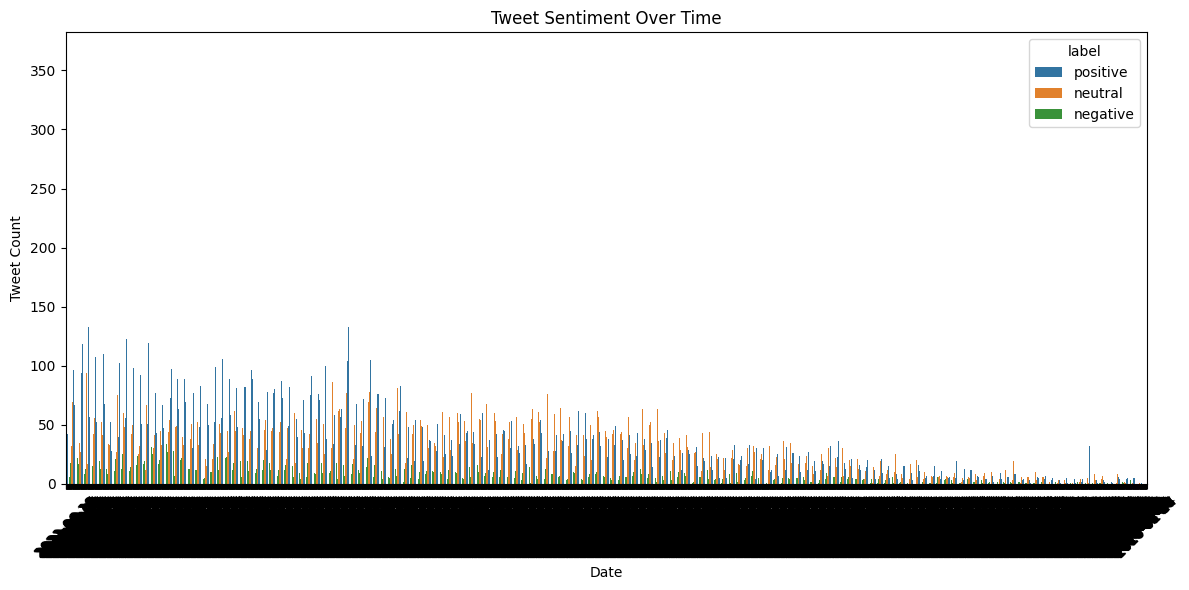

In [ ]:
df_all['created_at'] = pd.to_datetime(df_all['created_at'], errors='coerce')
df_all['date_only'] = df_all['created_at'].dt.date

plt.figure(figsize=(12,6))
sns.countplot(x='date_only', hue='label', data=df_all)
plt.xticks(rotation=45)
plt.title('Tweet Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Tweet Count')
plt.tight_layout()
plt.show()

##Top Tweeting Locations

<ipython-input-19-8c507c7d6376>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_places.values, y=top_places.index, palette='coolwarm')


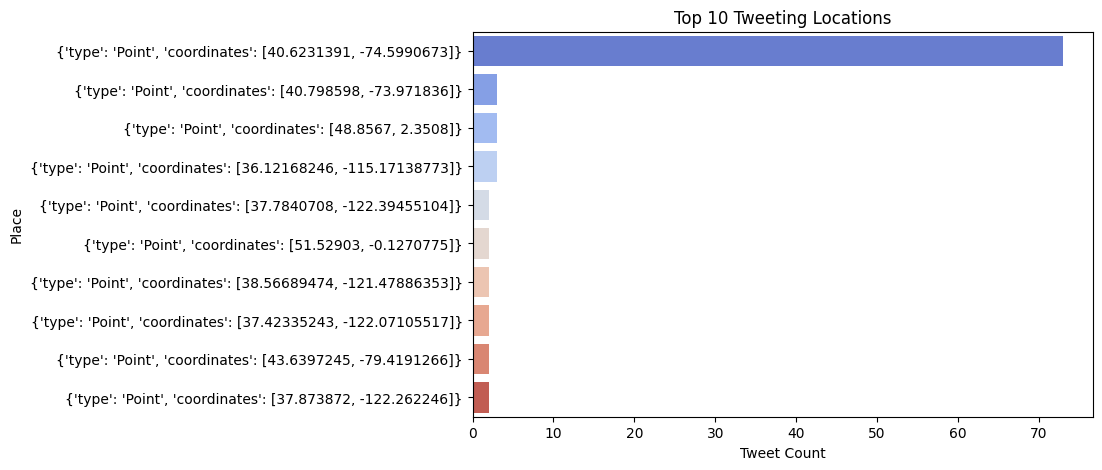

In [ ]:
top_places = df_all['place'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_places.values, y=top_places.index, palette='coolwarm')
plt.title('Top 10 Tweeting Locations')
plt.xlabel('Tweet Count')
plt.ylabel('Place')
plt.show()

#Text Preprocessing

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'@\w+|#', '', text)
    text = text.translate(str.maketrans('','',string.punctuation))
    text = re.sub(r'\d+', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t)>1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df_all['clean_text'] = df_all['tweet'].apply(clean_tweet)
print("Sample cleaned tweets:")
df_all[['tweet','clean_text']].head(3)

Sample cleaned tweets:


,tweet,clean_text
0,Join @SPJ_IC at 6 p.m. EDT Tuesday for the nex...,join pm edt tuesday next ictalk created code b...
1,"READ: Resilience, hard work, and perseverance ...",read resilience hard work perseverance paid ge...
2,How will the shift to streaming impact movie-m...,shift streaming impact moviemaking interesting...


#WordClouds by Sentiments

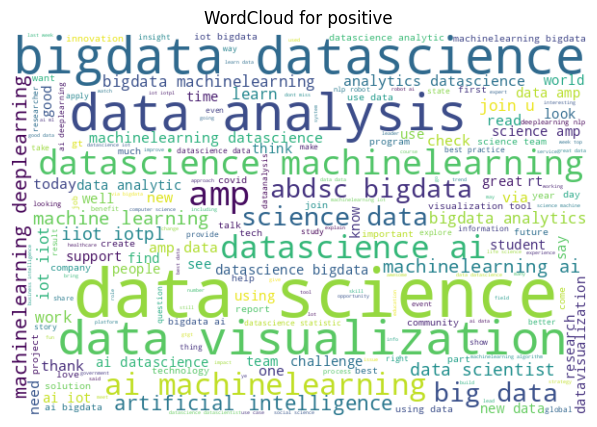

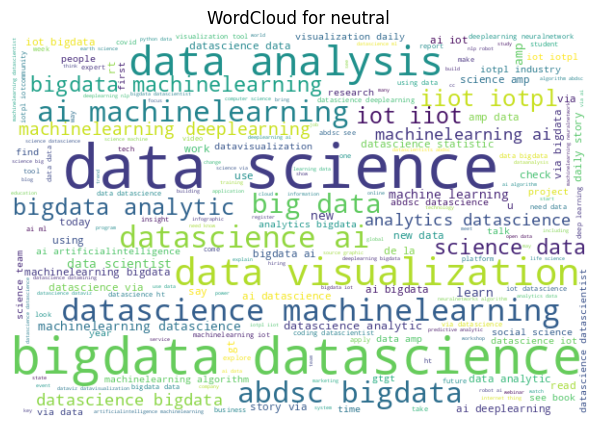

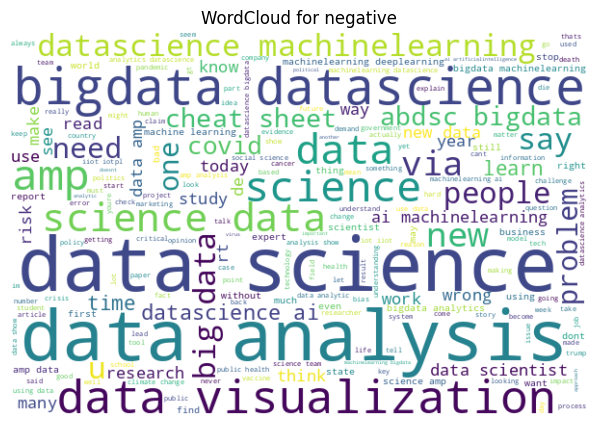

In [ ]:
for lbl in df_all['label'].unique():
    txt = ' '.join(df_all[df_all['label']==lbl]['clean_text'])
    wc = WordCloud(width=600, height=400, background_color='white').generate(txt)
    plt.figure(figsize=(8,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud for {lbl}')
    plt.show()

#Train-Test Split

In [ ]:
X = df_all['clean_text']
y = df_all['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (251273,) Test shape: (62819,)


#Model Pipelines & Evaluation


In [ ]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# ✅ Step 4: Train and evaluate each model
results = {}
for name, clf in models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,1), max_df=0.9, min_df=5)),  # unigram only
        ('clf', clf)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = {
        'Accuracy': acc,
        'Precision': precision_score(y_test, preds, average='weighted'),
        'Recall': recall_score(y_test, preds, average='weighted'),
        'F1': f1_score(y_test, preds, average='weighted')
    }

    print(f"\n--- {name} ---")
    print(classification_report(y_test, preds))
    print(f"✅ Overall Accuracy: {acc:.4f}")
    print("-" * 50)

# ✅ Optional: View final result scores
import pandas as pd
results_df = pd.DataFrame(results).T
display(results_df)


--- LogisticRegression ---
              precision    recall  f1-score   support

    negative       0.86      0.67      0.75      6233
     neutral       0.92      0.96      0.94     26010
    positive       0.94      0.95      0.95     30576

    accuracy                           0.93     62819
   macro avg       0.91      0.86      0.88     62819
weighted avg       0.92      0.93      0.92     62819

✅ Overall Accuracy: 0.9256
--------------------------------------------------

--- RandomForest ---
              precision    recall  f1-score   support

    negative       0.92      0.51      0.66      6233
     neutral       0.89      0.96      0.92     26010
    positive       0.91      0.94      0.93     30576

    accuracy                           0.90     62819
   macro avg       0.91      0.80      0.83     62819
weighted avg       0.90      0.90      0.90     62819

✅ Overall Accuracy: 0.9026
--------------------------------------------------


,Accuracy,Precision,Recall,F1
LogisticRegression,0.925580,0.924165,0.925580,0.923496
RandomForest,0.902561,0.903483,0.902561,0.896845


#Summary of Metrics

In [ ]:
metrics_df = pd.DataFrame(results).T
metrics_df

,Accuracy,Precision,Recall,F1
LogisticRegression,0.925580,0.924165,0.925580,0.923496
RandomForest,0.902561,0.903483,0.902561,0.896845


#Confusion Matrix for Best Model

Best model by F1: LogisticRegression


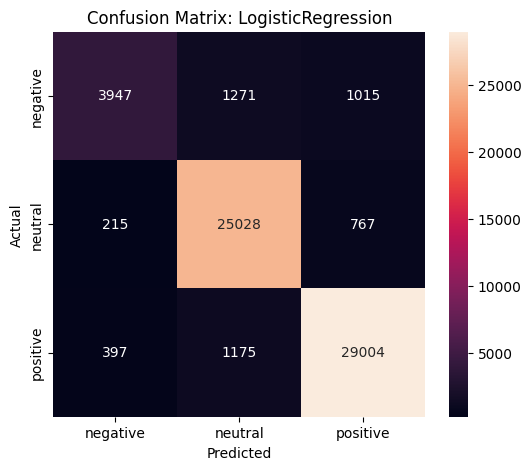

In [ ]:
best_model = max(results, key=lambda k: results[k]['F1'])
print("Best model by F1:", best_model)

best_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_df=0.9, min_df=5)),
    ('clf', models[best_model])
]).fit(X_train, y_train)

preds = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, preds, labels=best_pipe.classes_)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=best_pipe.classes_,
            yticklabels=best_pipe.classes_)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title(f'Confusion Matrix: {best_model}')
plt.show()

#Interactive Widgets for Live Testing

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

tweet_in = widgets.Text(placeholder='Type a tweet…', layout=widgets.Layout(width='80%'))
btn = widgets.Button(description="Predict")
out = widgets.Output()

def on_click(b):
    with out:
        clear_output()
        txt = clean_tweet(tweet_in.value)
        pred = best_pipe.predict([txt])[0]
        probs = best_pipe.predict_proba([txt])[0]
        print(f"**Predicted sentiment:** {pred}")
        for lab, p in zip(best_pipe.classes_, probs):
            print(f" • {lab}: {p:.1%}")

btn.on_click(on_click)
display(tweet_in, btn, out)

Text(value='', layout=Layout(width='80%'), placeholder='Type a tweet…')

Button(description='Predict', style=ButtonStyle())

Output()